In [1]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wo

True

In [3]:
text = "Machine learning is transforming the world. It helps computers learn from data and make predictions."
print('Original Text:\n', text)

Original Text:
 Machine learning is transforming the world. It helps computers learn from data and make predictions.


In [4]:
tokens = word_tokenize(text)
print('\nTokens:')
print(tokens)


Tokens:
['Machine', 'learning', 'is', 'transforming', 'the', 'world', '.', 'It', 'helps', 'computers', 'learn', 'from', 'data', 'and', 'make', 'predictions', '.']


In [5]:
pos = pos_tag(tokens)
print('\nPOS Tagging:')
print(pos)


POS Tagging:
[('Machine', 'NN'), ('learning', 'NN'), ('is', 'VBZ'), ('transforming', 'VBG'), ('the', 'DT'), ('world', 'NN'), ('.', '.'), ('It', 'PRP'), ('helps', 'VBZ'), ('computers', 'NNS'), ('learn', 'VBP'), ('from', 'IN'), ('data', 'NNS'), ('and', 'CC'), ('make', 'VB'), ('predictions', 'NNS'), ('.', '.')]


In [6]:
stop_words = set(stopwords.words('english'))
filtered_words = [word for word in tokens if word.lower() not in stop_words and word.isalpha()]
print('\nAfter Stop Word Removal:')
print(filtered_words)


After Stop Word Removal:
['Machine', 'learning', 'transforming', 'world', 'helps', 'computers', 'learn', 'data', 'make', 'predictions']


In [7]:
ps = PorterStemmer()
stemmed_words = [ps.stem(word) for word in filtered_words]
print('\nStemmed Words:')
print(stemmed_words)


Stemmed Words:
['machin', 'learn', 'transform', 'world', 'help', 'comput', 'learn', 'data', 'make', 'predict']


In [8]:
lm = WordNetLemmatizer()
lemmatized_words = [lm.lemmatize(word) for word in filtered_words]
print('\nLemmatized Words:')
print(lemmatized_words)


Lemmatized Words:
['Machine', 'learning', 'transforming', 'world', 'help', 'computer', 'learn', 'data', 'make', 'prediction']


In [9]:
documents = [
    "Machine learning is transforming the world",
    "Computers learn from data using machine learning",
    "Predictions are made using data science"
]

In [10]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(documents)

In [11]:
df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
print('\nTF-IDF Matrix:')
print(df)


TF-IDF Matrix:
        are  computers      data      from        is     learn  learning  \
0  0.000000   0.000000  0.000000  0.000000  0.440362  0.000000  0.334907   
1  0.000000   0.433816  0.329928  0.433816  0.000000  0.433816  0.329928   
2  0.440362   0.000000  0.334907  0.000000  0.000000  0.000000  0.000000   

    machine      made  predictions   science       the  transforming  \
0  0.334907  0.000000     0.000000  0.000000  0.440362      0.440362   
1  0.329928  0.000000     0.000000  0.000000  0.000000      0.000000   
2  0.000000  0.440362     0.440362  0.440362  0.000000      0.000000   

      using     world  
0  0.000000  0.440362  
1  0.329928  0.000000  
2  0.334907  0.000000  


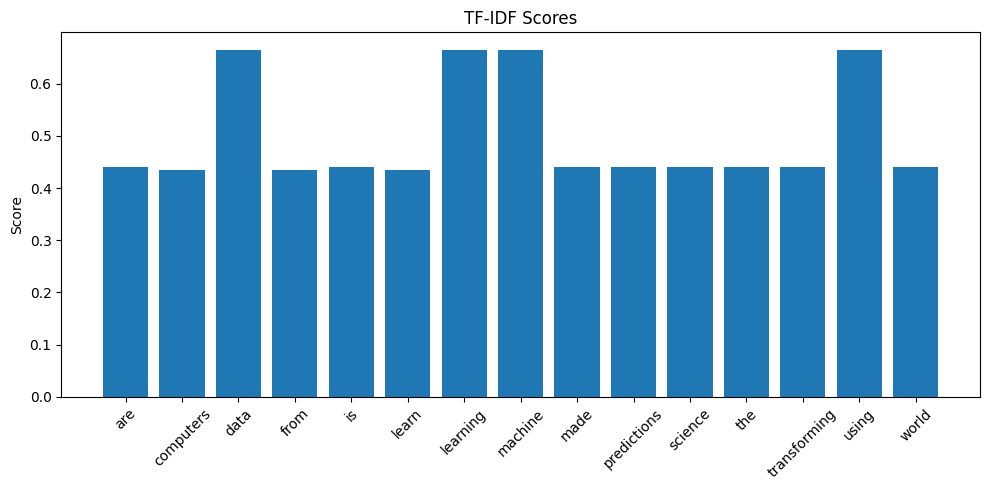

In [12]:
word_scores = df.sum()
plt.figure(figsize=(10,5))
plt.bar(word_scores.index, word_scores.values)
plt.title('TF-IDF Scores')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()